In [ ]:
# 1. Подключаем Google Диск к Colab
from google.colab import drive
drive.mount('/content/drive')

# 2. Импорт библиотек
import os
import pandas as pd

# 3. Указываем путь к папке с данными (как вы указали)
DATA_PATH = '/content/drive/MyDrive/Ucheba/Hakaton/sber_auto_data/'

# 4. Формируем полные пути к файлам
sessions_path = os.path.join(DATA_PATH, 'ga_sessions.csv')
hits_path = os.path.join(DATA_PATH, 'ga_hits.csv')

Mounted at /content/drive


In [ ]:
# ШАГ 1.2: Загрузка данных и первичный анализ

# 1. Импорт библиотек
import pandas as pd
import numpy as np
import time

# 2. Указываем пути к файлам
DATA_PATH = '/content/drive/MyDrive/Ucheba/Hakaton/sber_auto_data/'
sessions_path = DATA_PATH + 'ga_sessions.csv'
hits_path = DATA_PATH + 'ga_hits.csv'

# 3. Загрузка файла ga_sessions.csv (сессии)

print("Загружаем ga_sessions.csv...")
start_time = time.time()

# low_memory=False помогает pandas правильно определить типы столбцов с первого раза
df_sessions = pd.read_csv(sessions_path, low_memory=False)

elapsed = time.time() - start_time
print(f"ga_sessions.csv загружен за {elapsed:.2f} сек")
print(f"Размер: {df_sessions.shape[0]:,} строк × {df_sessions.shape[1]} столбцов\n")


# 4. Загрузка файла ga_hits.csv (события/хиты)

print("Загружаем ga_hits.csv...")
start_time = time.time()

# тоже используем low_memory=False
df_hits = pd.read_csv(hits_path, low_memory=False)

elapsed = time.time() - start_time
print(f"ga_hits.csv загружен за {elapsed:.2f} сек")
print(f"Размер: {df_hits.shape[0]:,} строк × {df_hits.shape[1]} столбцов\n")

Загружаем ga_sessions.csv...
ga_sessions.csv загружен за 23.55 сек
Размер: 1,860,042 строк × 18 столбцов

Загружаем ga_hits.csv...
ga_hits.csv загружен за 140.36 сек
Размер: 15,726,470 строк × 11 столбцов



In [ ]:
# 5. Детальный анализ структуры: метод .info()

print("АНАЛИЗ СТРУКТУРЫ ДАННЫХ")


print("ga_sessions.csv — информация о столбцах:")

df_sessions.info()

print ()

print("ga_hits.csv — информация о столбцах:")

df_hits.info()

АНАЛИЗ СТРУКТУРЫ ДАННЫХ
ga_sessions.csv — информация о столбцах:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 18 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   session_id                object
 1   client_id                 object
 2   visit_date                object
 3   visit_time                object
 4   visit_number              int64 
 5   utm_source                object
 6   utm_medium                object
 7   utm_campaign              object
 8   utm_adcontent             object
 9   utm_keyword               object
 10  device_category           object
 11  device_os                 object
 12  device_brand              object
 13  device_model              object
 14  device_screen_resolution  object
 15  device_browser            object
 16  geo_country               object
 17  geo_city                  object
dtypes: int64(1), object(17)
memory usage: 255.4+ MB

ga_hits.

In [ ]:
 Почти все столбцы — текстовые (object). Это значит, что перед обучением модели их нужно будет превратить в числа. Обе таблицы содержат session_id, правильно будет соединить их по этому столбцу.

In [ ]:
# 6. Считаем пропуски (NaN)

print()
print("\n ga_sessions.csv — пропуски по столбцам:")
missing_sessions = df_sessions.isna().sum()
# Показываем только столбцы, где есть пропуски
if missing_sessions.sum() > 0:
    print(missing_sessions[missing_sessions > 0])
    print(f"\n Всего пропусков: {missing_sessions.sum():,} ({missing_sessions.sum() / df_sessions.size * 100:.2f}% от всех ячеек)")
else:
    print(" Пропусков нет!")

print("\n ga_hits.csv — пропуски по столбцам:")
missing_hits = df_hits.isna().sum()
if missing_hits.sum() > 0:
    print(missing_hits[missing_hits > 0])
    print(f"\n Всего пропусков: {missing_hits.sum():,} ({missing_hits.sum() / df_hits.size * 100:.2f}% от всех ячеек)")
else:
    print(" Пропусков нет!")

# 7. Проверяем дубликаты

dup_sessions = df_sessions.duplicated().sum()
dup_hits = df_hits.duplicated().sum()

print(f" ga_sessions.csv: {dup_sessions:,} дубликатов строк ({dup_sessions / len(df_sessions) * 100:.2f}%)")
print(f" ga_hits.csv: {dup_hits:,} дубликатов строк ({dup_hits / len(df_hits) * 100:.2f}%)")

# 8. Найдем числовые столбцы

print("\n ga_sessions.csv — describe():")
print(df_sessions.describe(include='number').round(2))

print("\n ga_hits.csv — describe():")
print(df_hits.describe(include='number').round(2))

#  Сохраняем промежуточный результат в Parquet быстрее читается и занимает меньше места

df_sessions.to_parquet('/content/drive/MyDrive/Ucheba/Hakaton/sessions_checkpoint.parquet', index=False)
df_hits.to_parquet('/content/drive/MyDrive/Ucheba/Hakaton/hits_checkpoint.parquet', index=False)

print("      /content/drive/MyDrive/Ucheba/Hakaton/sessions_checkpoint.parquet")
print("      /content/drive/MyDrive/Ucheba/Hakaton/hits_checkpoint.parquet")




 ga_sessions.csv — пропуски по столбцам:
utm_source            97
utm_campaign      219603
utm_adcontent     335615
utm_keyword      1082061
device_os        1070138
device_brand      367178
device_model     1843704
dtype: int64

 Всего пропусков: 4,918,396 (14.69% от всех ячеек)

 ga_hits.csv — пропуски по столбцам:
hit_time        9160322
hit_referer     6274804
event_label     3760184
event_value    15726470
dtype: int64

 Всего пропусков: 34,921,780 (20.19% от всех ячеек)
 ga_sessions.csv: 0 дубликатов строк (0.00%)
 ga_hits.csv: 0 дубликатов строк (0.00%)

 ga_sessions.csv — describe():
       visit_number
count    1860042.00
mean           2.71
std           11.83
min            1.00
25%            1.00
50%            1.00
75%            2.00
max          564.00

 ga_hits.csv — describe():
          hit_time   hit_number  event_value
count   6566148.00  15726470.00          0.0
mean     209104.99        23.57          NaN
std      403210.97        28.88          NaN
min        

В таблице действий: столбец event_value пуст на 100% — его можно удалить, он бесполезен.

visit_number: медиана = 1, среднее = 2,71. Это значит, что большинство пользователей заходят на сайт впервые, но есть и постоянные посетители (максимум — 564 визита от одного человека).

hit_number (номер действия в сессии): медиана = 15. То есть типичный пользователь делает около 15 действий за один визит.

hit_time: большой разброс (от 0 до 13 млн секунд) — это время в секундах с начала дня, поэтому значения такие большие.

In [ ]:
# ШАГ 1.3: Приведение типов и базовая очистка
import pandas as pd
import numpy as np
# 1. Загружаем чекпоинты
df_sessions = pd.read_parquet('/content/drive/MyDrive/Ucheba/Hakaton/sessions_checkpoint.parquet')
df_hits = pd.read_parquet('/content/drive/MyDrive/Ucheba/Hakaton/hits_checkpoint.parquet')

# 2. Удаляем бесполезные столбцы (100% или ~99% пропусков)

# В ga_hits: event_value — все пропуски
if 'event_value' in df_hits.columns:
    df_hits = df_hits.drop(columns=['event_value'])
    print("      Удалён столбец 'event_value' из hits (100% пропусков)")

# В ga_sessions: device_model — 99.1% пропусков
if 'device_model' in df_sessions.columns:
    df_sessions = df_sessions.drop(columns=['device_model'])
    print("      Удалён столбец 'device_model' из sessions (99.1% пропусков)")

# 3. Заполняем пропуски в категориальных столбцах значением 'unknown'

# Список столбцов для заполнения
categorical_cols_to_fill = [
    'utm_source', 'utm_campaign', 'utm_adcontent', 'utm_keyword',
    'device_os', 'device_brand', 'device_category', 'device_browser',
    'geo_country', 'geo_city'
]

for col in categorical_cols_to_fill:
    if col in df_sessions.columns:
        # Заполняем пропуски строкой 'unknown'
        df_sessions[col] = df_sessions[col].fillna('unknown')
        print(f"    {col}: заполнено {df_sessions[col].value_counts().get('unknown', 0)} пропусков")

# В hits: заполняем hit_referer и event_label
if 'hit_referer' in df_hits.columns:
    df_hits['hit_referer'] = df_hits['hit_referer'].fillna('unknown')
    print("    hit_referer: заполнено 'unknown'")

if 'event_label' in df_hits.columns:
    df_hits['event_label'] = df_hits['event_label'].fillna('unknown')
    print("    event_label: заполнено 'unknown'")

# 4. Приводим даты к правильному формату

print("\n Приводим даты к формату datetime...")

# В sessions
df_sessions['visit_date'] = pd.to_datetime(df_sessions['visit_date'], errors='coerce')
df_sessions['visit_time'] = pd.to_datetime(
    df_sessions['visit_time'],
    errors='coerce',
    format='mixed'
)

# В hits
df_hits['hit_date'] = pd.to_datetime(df_hits['hit_date'], errors='coerce')
# hit_time — это число секунд с начала дня, преобразуем в timedelta
df_hits['hit_time'] = pd.to_timedelta(df_hits['hit_time'], unit='s', errors='coerce')

print(" Даты преобразованы")

# 5. Создаём целевую переменную (target)

# print("\n Создаём целевую переменную 'target'...")

# Список целевых действий
target_events = [
    'sub_car_claim_click',      # клик по заявке
    'click_call',               # заказ звонка
    'open_dialog',              # открытие диалога
    'submit_form',              # отправка формы
    # добавьте другие, если они есть в ваших данных
]

# Помечаем хиты как целевые
df_hits['is_target'] = df_hits['event_action'].isin(target_events)

# Для каждой сессии: 1 если был хоть один целевой хит, иначе 0
target_by_session = df_hits.groupby('session_id')['is_target'].any()

# Добавляем target в sessions
df_sessions = df_sessions.set_index('session_id')
df_sessions['target'] = target_by_session
df_sessions['target'] = df_sessions['target'].fillna(False).infer_objects(copy=False).astype(int)
df_sessions = df_sessions.reset_index()

# Считаем конверсию
conversion_rate = df_sessions['target'].mean() * 100
print(f" Целевая переменная создана")
print(f" Конверсия: {conversion_rate:.2f}% ({df_sessions['target'].sum():,} целевых сессий из {len(df_sessions):,})")

# 6. Базовая обработка выбросов в visit_number

# Ограничиваем visit_number 95-м перцентилем (значение 50)
df_sessions['visit_number_clean'] = df_sessions['visit_number'].clip(upper=50)

#  Сохраняем очищенные данные

df_sessions.to_parquet('/content/drive/MyDrive/Ucheba/Hakaton/sessions_step1_3.parquet', index=False)
df_hits.to_parquet('/content/drive/MyDrive/Ucheba/Hakaton/hits_step1_3.parquet', index=False)
print("Очещенные данные сохранены:")
print("   /content/drive/MyDrive/Ucheba/Hakaton/sessions_step1_3.parquet")
print("   /content/drive/MyDrive/Ucheba/Hakaton/hits_step1_3.parquet")

      Удалён столбец 'event_value' из hits (100% пропусков)
      Удалён столбец 'device_model' из sessions (99.1% пропусков)
    utm_source: заполнено 97 пропусков
    utm_campaign: заполнено 219603 пропусков
    utm_adcontent: заполнено 335615 пропусков
    utm_keyword: заполнено 1082061 пропусков
    device_os: заполнено 1070138 пропусков
    device_brand: заполнено 367178 пропусков
    device_category: заполнено 0 пропусков
    device_browser: заполнено 0 пропусков
    geo_country: заполнено 0 пропусков
    geo_city: заполнено 0 пропусков
    hit_referer: заполнено 'unknown'
    event_label: заполнено 'unknown'

 Приводим даты к формату datetime...
 Даты преобразованы


/tmp/ipykernel_3102/1281192294.py:85: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_sessions['target'] = df_sessions['target'].fillna(False).infer_objects(copy=False).astype(int)


 Целевая переменная создана
 Конверсия: 1.70% (31,712 целевых сессий из 1,860,042)
Очещенные данные сохранены:
   /content/drive/MyDrive/Ucheba/Hakaton/sessions_step1_3.parquet
   /content/drive/MyDrive/Ucheba/Hakaton/hits_step1_3.parquet


На данном шаге произведена подготовка данных для обучения: удалены пустые колонки, заменены пропуски на «неизвестно», даты переведены в удобный формат и пометили, какие визиты привели к заявке.

 Загружаем данные...
 Загружено 1,860,042 строк

 График 1: Распределение target


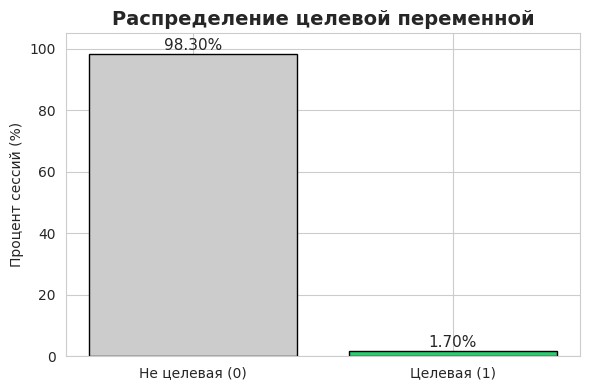

 Вывод: Конверсия = 1.70%

 График 2: Конверсия по device_category


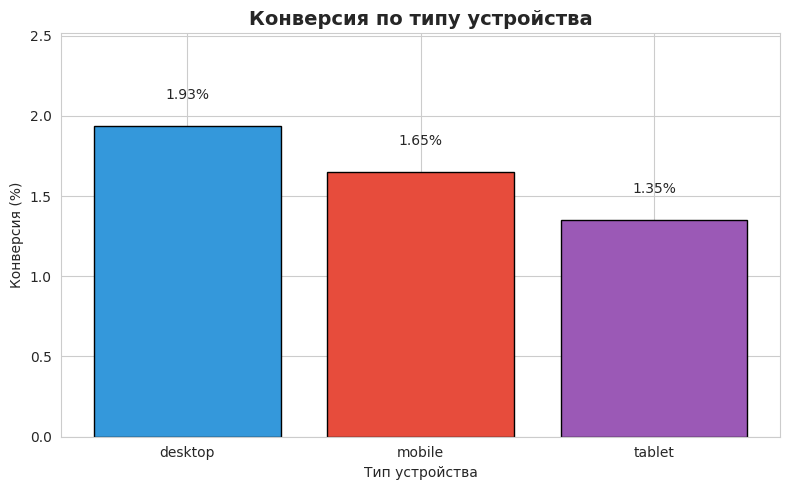

 Вывод: Лучшая конверсия у 'desktop' (1.93%)

 График 3: Конверсия по часам суток


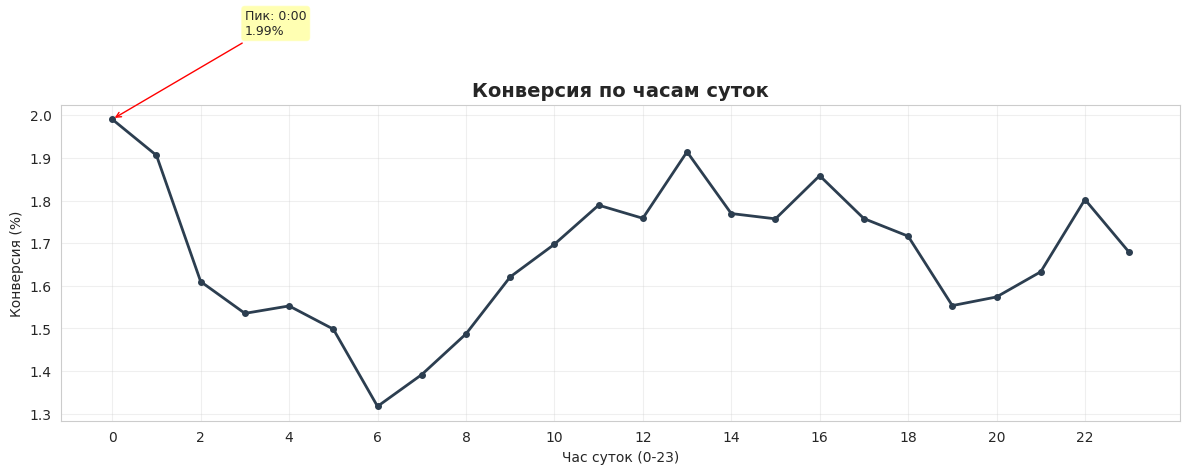

 Вывод: Лучшее время для рекламы — 0:00 (1.99% конверсии)

 Сохраняем выводы...
 Выводы сохранены в /content/drive/MyDrive/Ucheba/Hakaton/eda_summary_step1_4.txt
 Чекпоинт сохранен:/content/drive/MyDrive/Ucheba/Hakaton//sessions_step1_4.parquet
   Общая конверсия: 1.70%
   Лучшее устройство: desktop
   Пиковый час: 0:00


In [ ]:
# ШАГ 1.4: Разведочный анализ (EDA)

# 1. Загружаем библиотеки и данные
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки для красивых графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

# Загружаем чекпоинты
print(" Загружаем данные...")
df_sessions = pd.read_parquet('/content/drive/MyDrive/Ucheba/Hakaton/sessions_step1_3.parquet')
print(f" Загружено {len(df_sessions):,} строк")


# 2. График 1: Распределение целевой переменной (target)

print("\n График 1: Распределение target")

# Считаем проценты
target_counts = df_sessions['target'].value_counts(normalize=True) * 100

# Строим бар-чарт
plt.figure(figsize=(6, 4))
bars = plt.bar(['Не целевая (0)', 'Целевая (1)'],
               [target_counts[0], target_counts[1]],
               color=['#cccccc', '#2ecc71'], edgecolor='black')

# Добавляем подписи значений на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.3,
             f'{height:.2f}%', ha='center', va='bottom', fontsize=11)

plt.title('Распределение целевой переменной', fontsize=14, fontweight='bold')
plt.ylabel('Процент сессий (%)')
plt.ylim(0, 105)  # Немного места сверху для подписей
plt.tight_layout()
plt.show()

print(f" Вывод: Конверсия = {target_counts[1]:.2f}%")

# 3. График 2: Конверсия по типу устройства (device_category)

print("\n График 2: Конверсия по device_category")

# Группируем по устройству и считаем среднее target (это и есть конверсия)
conv_by_device = df_sessions.groupby('device_category')['target'].mean() * 100

# Сортируем по убыванию конверсии для наглядности
conv_by_device = conv_by_device.sort_values(ascending=False)

# Строим бар-чарт
plt.figure(figsize=(8, 5))
bars = plt.bar(conv_by_device.index, conv_by_device.values,
               color=['#3498db', '#e74c3c', '#9b59b6'], edgecolor='black')

# Добавляем подписи значений
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.15,
             f'{height:.2f}%', ha='center', va='bottom', fontsize=10)

plt.title('Конверсия по типу устройства', fontsize=14, fontweight='bold')
plt.ylabel('Конверсия (%)')
plt.xlabel('Тип устройства')
plt.ylim(0, conv_by_device.max() * 1.3)  # Место для подписей
plt.tight_layout()
plt.show()

print(f" Вывод: Лучшая конверсия у '{conv_by_device.idxmax()}' ({conv_by_device.max():.2f}%)")


# 4. График 3: Конверсия по часам суток (visit_time_hour)

print("\n График 3: Конверсия по часам суток")

# Извлекаем час из visit_time (если еще не извлекли)
if 'visit_time_hour' not in df_sessions.columns:
    df_sessions['visit_time_hour'] = df_sessions['visit_time'].dt.hour

# Группируем по часу и считаем конверсию
conv_by_hour = df_sessions.groupby('visit_time_hour')['target'].mean() * 100

# Строим линейный график
plt.figure(figsize=(12, 5))
plt.plot(conv_by_hour.index, conv_by_hour.values,
         marker='o', linewidth=2, markersize=4, color='#2c3e50')

# Добавляем сетку и подписи
plt.grid(True, alpha=0.3)
plt.title('Конверсия по часам суток', fontsize=14, fontweight='bold')
plt.ylabel('Конверсия (%)')
plt.xlabel('Час суток (0-23)')
plt.xticks(range(0, 24, 2))  # Подписи каждые 2 часа

# Находим час с максимальной конверсией
best_hour = conv_by_hour.idxmax()
best_conv = conv_by_hour.max()
plt.annotate(f'Пик: {best_hour}:00\n{best_conv:.2f}%',
             xy=(best_hour, best_conv),
             xytext=(best_hour+3, best_conv*1.1),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.show()

print(f" Вывод: Лучшее время для рекламы — {best_hour}:00 ({best_conv:.2f}% конверсии)")


# 5. Сохраняем выводы в текстовый файл (для отчета)

print("\n Сохраняем выводы...")

with open('/content/drive/MyDrive/Ucheba/Hakaton/eda_summary_step1_4.txt', 'w', encoding='utf-8') as f:
    f.write(" ВЫВОДЫ ПО ШАГУ 1.4 (EDA)\n")
    f.write("="*50 + "\n\n")
    f.write(f"   Общая конверсия: {target_counts[1]:.2f}%\n")
    f.write(f"   Лучшее устройство: {conv_by_device.idxmax()} ({conv_by_device.max():.2f}%)\n")
    f.write(f"   Лучший час: {best_hour}:00 ({best_conv:.2f}%)\n")
    f.write(f"   Всего сессий: {len(df_sessions):,}\n")
    f.write(f"   Целевых сессий: {df_sessions['target'].sum():,}\n")

print(" Выводы сохранены в /content/drive/MyDrive/Ucheba/Hakaton/eda_summary_step1_4.txt")


#  Сохраняем данные с новыми признаками


df_sessions.to_parquet('/content/drive/MyDrive/Ucheba/Hakaton//sessions_step1_4.parquet', index=False)
print(" Чекпоинт сохранен:/content/drive/MyDrive/Ucheba/Hakaton//sessions_step1_4.parquet")


#  ВЫВОД

print(f"   Общая конверсия: {target_counts[1]:.2f}%")
print(f"   Лучшее устройство: {conv_by_device.idxmax()}")
print(f"   Пиковый час: {best_hour}:00")

График 1: Распределение целевой переменной

Показывает соотношение обычных посетителей сайта и тех, кто оставил заявку.

Из каждых 100 посетителей сайта только 1-2 человека оставляют заявку.

График 2: Конверсия по типу устройства

Показывает с какого устройства чаще оставляют заявки пользователи.

График 3: Конверсия по часам суток

Показывает в какое время люди чаще всего оставляют заявки.

 Загружено 1,860,042 строк
 Числовые признаки: ['visit_number', 'visit_number_clean', 'target', 'visit_date_day', 'visit_date_month', 'visit_time_hour']

 Корреляция с target:
target                1.000000
visit_number          0.011727
visit_date_day        0.006991
visit_number_clean    0.006628
visit_time_hour      -0.000006
visit_date_month     -0.051705
Name: target, dtype: float64


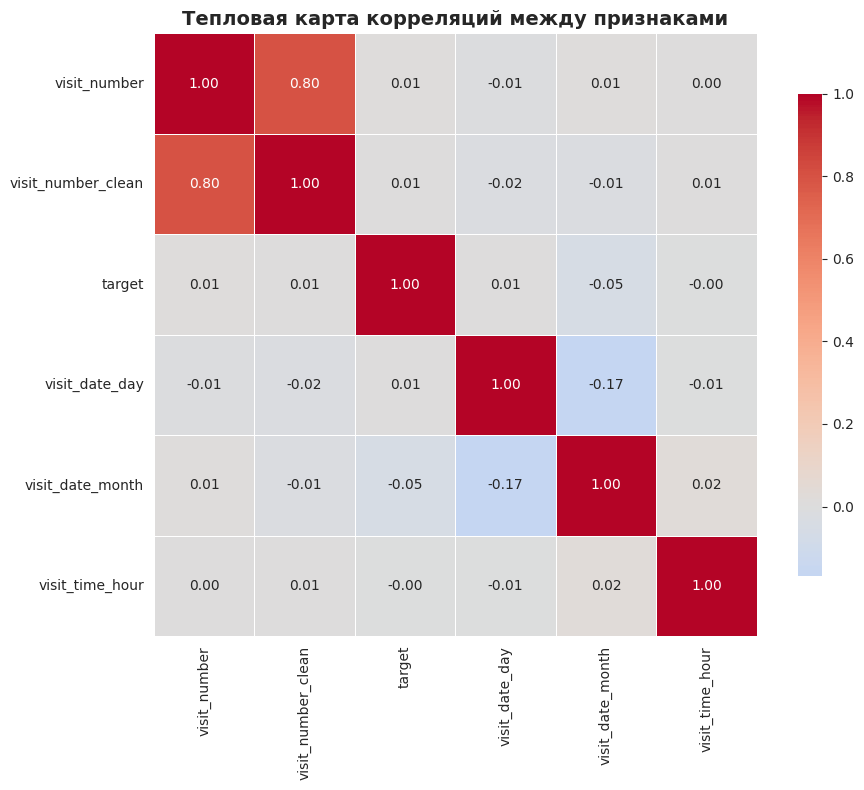


 Топ-5 признаков по корреляции с target:
     visit_date_month         : -0.0517
     visit_number             : +0.0117
     visit_date_day           : +0.0070
     visit_number_clean       : +0.0066
     visit_time_hour          : -0.0000

 Мультиколлинеарность (корреляции > 0.8):
 Высокой мультиколлинеарности нет!
1. Лучшая корреляция с target: 'visit_date_month' (-0.0517)
2. Всего признаков для анализа: 6
3. Пар с высокой корреляцией (>0.8): 0
 Чекпоинт сохранен: /content/drive/MyDrive/Ucheba/Hakaton/sessions_step1_5.parquet


In [ ]:
# ШАГ 1.5: Корреляционный анализ и тепловая карта

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загружаем чекпоинт

df_sessions = pd.read_parquet('/content/drive/MyDrive/Ucheba/Hakaton/sessions_step1_4.parquet')
print(f" Загружено {len(df_sessions):,} строк")


# 2. Выбираем числовые признаки для корреляции


# Числовые признаки (включая target)
numeric_cols = ['visit_number', 'visit_number_clean', 'target']

# Добавим время и дату как числа
df_sessions['visit_date_day'] = df_sessions['visit_date'].dt.day
df_sessions['visit_date_month'] = df_sessions['visit_date'].dt.month
df_sessions['visit_time_hour'] = df_sessions['visit_time'].dt.hour

numeric_cols.extend(['visit_date_day', 'visit_date_month', 'visit_time_hour'])

# Создаём датафрейм только с числовыми признаками
df_numeric = df_sessions[numeric_cols].copy()

print(f" Числовые признаки: {numeric_cols}")

# 3. Считаем корреляционную матрицу

corr_matrix = df_numeric.corr()

print("\n Корреляция с target:")
print(corr_matrix['target'].sort_values(ascending=False))

# 4. Строим тепловую карту (heatmap)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,      # Показывать значения
            fmt='.2f',       # Формат: 2 знака после запятой
            cmap='coolwarm', # Цветовая схема
            center=0,        # Центр на 0 (нет корреляции)
            square=True,     # Квадратные ячейки
            linewidths=0.5,  # Линии между ячейками
            cbar_kws={"shrink": 0.8})

plt.title('Тепловая карта корреляций между признаками', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 5. Анализируем корреляции с target

# Сортируем по абсолютному значению корреляции
corr_with_target = corr_matrix['target'].drop('target').abs().sort_values(ascending=False)

print("\n Топ-5 признаков по корреляции с target:")
for col in corr_with_target.head(5).index:
    corr_val = corr_matrix.loc[col, 'target']
    print(f"     {col:25s}: {corr_val:+.4f}")

# Проверка на мультиколлинеарность (корреляции между признаками > 0.8)
print("\n Мультиколлинеарность (корреляции > 0.8):")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.8 and col1 != 'target' and col2 != 'target':
            high_corr_pairs.append((col1, col2, corr_val))
            print(f"     {col1:25s} ↔ {col2:25s}: {corr_val:+.4f}")

if not high_corr_pairs:
    print(" Высокой мультиколлинеарности нет!")

# 6. Выводы для отчёта

# Находим лучшую корреляцию
best_corr = corr_matrix['target'].drop('target')
best_feature = best_corr.abs().idxmax()
best_value = best_corr[best_feature]

print(f"1. Лучшая корреляция с target: '{best_feature}' ({best_value:+.4f})")
print(f"2. Всего признаков для анализа: {len(numeric_cols)}")
print(f"3. Пар с высокой корреляцией (>0.8): {len(high_corr_pairs)}")

if len(high_corr_pairs) > 0:
    print("   → Рекомендуется удалить один признак из каждой пары")

# Сохраняем данные с новыми признаками

df_sessions.to_parquet('/content/drive/MyDrive/Ucheba/Hakaton/sessions_step1_5.parquet', index=False)
print(" Чекпоинт сохранен: /content/drive/MyDrive/Ucheba/Hakaton/sessions_step1_5.parquet")

Тепловая карта показывает, как разные числовые признаки связаны друг с другом и с целевой переменной target — будет ли заявка.

Текущие числовые признаки (номер визита, день, месяц, час) почти не помогают предсказать конверсию. Поэтому необходимо будет создавать другие, более информативные признаки.

    Sessions: 1,860,042 строк × 22 столбцов
    Hits: 15,726,470 строк × 11 столбцов

 Статистика:
    Всего строк: 1,860,042
    Уникальных session_id: 1,860,042
    Дубликатов: 0 (0.00%)

 Все session_id уникальны! Каждая строка — это отдельный визит.

 Количество уникальных сессий:
    В ga_sessions: 1,860,042
    В ga_hits: 1,734,610
    Сессии только в sessions (нет в hits): 127,776
    Сессии только в hits (нет в sessions): 2,344
    127,776 сессий без событий (hits)!
    2,344 событий без сессий (orphan hits)!
    Всего сессий с событиями: 1,734,610
    Всего событий (hits): 15,726,470
    Среднее hits на сессию: 9.1
    Медиана hits на сессию: 4
    Минимум: 1
    Максимум: 768

 Процентили:
    25% сессий имеют ≤ 1 событий
    50% сессий имеют ≤ 4 событий
    75% сессий имеют ≤ 11 событий
    95% сессий имеют ≤ 34 событий


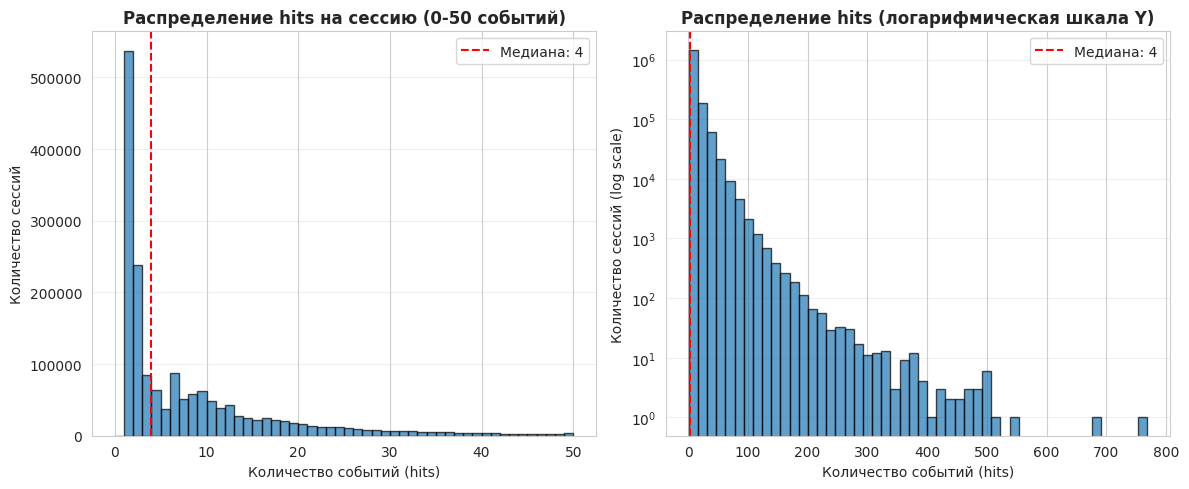


 Пример сессии с 1 событием:
   Session ID: 4555021455660578227.1626240445.1626240445...
   Количество hits: 1

 Пример сессии с медианным количеством (4 событий):
   Session ID: 5953257031058733045.1624913909.1624914055...
   Количество hits: 4

 Пример сессии с большим количеством событий:
   Session ID: 1382984186821927761.1635836752.1635836752...
   Количество hits: 100
   Все session_id в ga_sessions уникальны
    Сессии без событий (hits): 127,776
    События без сессий (orphan hits): 2,344
    Нет пропусков в session_id (sessions)
    Нет пропусков в session_id (hits)
Статистика сохранена в /content/drive/MyDrive/Ucheba/Hakaton/data_structure_analysis.txt
    /content/drive/MyDrive/Ucheba/Hakaton/sessions_step1_6.parquet
    /content/drive/MyDrive/Ucheba/Hakaton/hits_step1_6.parquet


In [ ]:
# ШАГ 1.6: Анализ структуры данных и связей между таблицами

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Загружаем чекпоинты

df_sessions = pd.read_parquet('/content/drive/MyDrive/Ucheba/Hakaton/sessions_step1_5.parquet')
df_hits = pd.read_parquet('/content/drive/MyDrive/Ucheba/Hakaton/hits_step1_3.parquet')

print(f"    Sessions: {df_sessions.shape[0]:,} строк × {df_sessions.shape[1]} столбцов")
print(f"    Hits: {df_hits.shape[0]:,} строк × {df_hits.shape[1]} столбцов")

# 2. Проверка уникальности session_id в ga_sessions

total_sessions = len(df_sessions)
unique_sessions = df_sessions['session_id'].nunique()
duplicate_sessions = total_sessions - unique_sessions

print(f"\n Статистика:")
print(f"    Всего строк: {total_sessions:,}")
print(f"    Уникальных session_id: {unique_sessions:,}")
print(f"    Дубликатов: {duplicate_sessions:,} ({duplicate_sessions/total_sessions*100:.2f}%)")

if duplicate_sessions == 0:
    print("\n Все session_id уникальны! Каждая строка — это отдельный визит.")
else:
    print(f"\n  Найдено {duplicate_sessions:,} дубликатов session_id!")
    print("   Это может означать, что одна сессия разбита на несколько строк.")

# 3. Проверка связи ga_sessions и ga_hits (one-to-many)

# Сколько сессий есть в hits
sessions_in_hits = df_hits['session_id'].nunique()
sessions_in_sessions = df_sessions['session_id'].nunique()

print(f"\n Количество уникальных сессий:")
print(f"    В ga_sessions: {sessions_in_sessions:,}")
print(f"    В ga_hits: {sessions_in_hits:,}")

# Сопоставление сессии из sessions с hits
sessions_only_in_sessions = set(df_sessions['session_id']) - set(df_hits['session_id'])
sessions_only_in_hits = set(df_hits['session_id']) - set(df_sessions['session_id'])

print(f"    Сессии только в sessions (нет в hits): {len(sessions_only_in_sessions):,}")
print(f"    Сессии только в hits (нет в sessions): {len(sessions_only_in_hits):,}")

if len(sessions_only_in_sessions) > 0:
    print(f"    {len(sessions_only_in_sessions):,} сессий без событий (hits)!")

if len(sessions_only_in_hits) > 0:
    print(f"    {len(sessions_only_in_hits):,} событий без сессий (orphan hits)!")


# 4. Статистика: сколько хитов на одну сессию

# Считаем количество хитов на каждую сессию
hits_per_session = df_hits.groupby('session_id').size()

print(f"    Всего сессий с событиями: {len(hits_per_session):,}")
print(f"    Всего событий (hits): {len(df_hits):,}")
print(f"    Среднее hits на сессию: {hits_per_session.mean():.1f}")
print(f"    Медиана hits на сессию: {hits_per_session.median():.0f}")
print(f"    Минимум: {hits_per_session.min()}")
print(f"    Максимум: {hits_per_session.max():,}")

# Процентили
print(f"\n Процентили:")
print(f"    25% сессий имеют ≤ {hits_per_session.quantile(0.25):.0f} событий")
print(f"    50% сессий имеют ≤ {hits_per_session.quantile(0.50):.0f} событий")
print(f"    75% сессий имеют ≤ {hits_per_session.quantile(0.75):.0f} событий")
print(f"    95% сессий имеют ≤ {hits_per_session.quantile(0.95):.0f} событий")


# 5. Визуализация распределения (гистограмма)

plt.figure(figsize=(12, 5))

# Основная гистограмма (до 50 событий)
plt.subplot(1, 2, 1)
hits_per_session_clipped = hits_per_session[hits_per_session <= 50]
plt.hist(hits_per_session_clipped, bins=range(0, 51), edgecolor='black', alpha=0.7)
plt.title('Распределение hits на сессию (0-50 событий)', fontweight='bold')
plt.xlabel('Количество событий (hits)')
plt.ylabel('Количество сессий')
plt.axvline(hits_per_session.median(), color='red', linestyle='--',
            label=f'Медиана: {hits_per_session.median():.0f}')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Логарифмическая шкала для хвоста
plt.subplot(1, 2, 2)
plt.hist(hits_per_session, bins=50, edgecolor='black', alpha=0.7)
plt.title('Распределение hits (логарифмическая шкала Y)', fontweight='bold')
plt.xlabel('Количество событий (hits)')
plt.ylabel('Количество сессий (log scale)')
plt.yscale('log')
plt.axvline(hits_per_session.median(), color='red', linestyle='--',
            label=f'Медиана: {hits_per_session.median():.0f}')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Примеры сессий с разным количеством событий

# Сессии с 1 событием
sessions_1_hit = hits_per_session[hits_per_session == 1].sample(1).index[0]
# Сессии с медианным количеством
median_hits = int(hits_per_session.median())
sessions_median = hits_per_session[hits_per_session == median_hits].sample(1).index[0]
# Сессии с большим количеством событий
sessions_many_hits = hits_per_session[hits_per_session >= 100].sample(1).index[0]

print(f"\n Пример сессии с 1 событием:")
print(f"   Session ID: {sessions_1_hit[:50]}...")
print(f"   Количество hits: {hits_per_session[sessions_1_hit]}")

print(f"\n Пример сессии с медианным количеством ({median_hits} событий):")
print(f"   Session ID: {sessions_median[:50]}...")
print(f"   Количество hits: {hits_per_session[sessions_median]}")

print(f"\n Пример сессии с большим количеством событий:")
print(f"   Session ID: {sessions_many_hits[:50]}...")
print(f"   Количество hits: {hits_per_session[sessions_many_hits]:,}")


# 7. Проверка целостности данных

issues = []

# Проверка 1: дубликаты session_id в sessions
if duplicate_sessions > 0:
    issues.append(f" Дубликаты session_id в ga_sessions: {duplicate_sessions:,}")
else:
    issues.append("Все session_id в ga_sessions уникальны")

# Проверка 2: сессии без событий
if len(sessions_only_in_sessions) > 0:
    issues.append(f" Сессии без событий (hits): {len(sessions_only_in_sessions):,}")
else:
    issues.append(" Все сессии имеют хотя бы одно событие")

# Проверка 3: orphan hits
if len(sessions_only_in_hits) > 0:
    issues.append(f" События без сессий (orphan hits): {len(sessions_only_in_hits):,}")
else:
    issues.append(" Все события привязаны к сессиям")

# Проверка 4: пропуски в session_id
if df_sessions['session_id'].isna().sum() > 0:
    issues.append(f" Пропуски в session_id (sessions): {df_sessions['session_id'].isna().sum():,}")
else:
    issues.append(" Нет пропусков в session_id (sessions)")

if df_hits['session_id'].isna().sum() > 0:
    issues.append(f" Пропуски в session_id (hits): {df_hits['session_id'].isna().sum():,}")
else:
    issues.append(" Нет пропусков в session_id (hits)")

# Выводим все проверки
for issue in issues:
    print(f"   {issue}")


#  Сохраняем результаты анализа и сохраняем статистику в текстовый файл
with open('/content/drive/MyDrive/Ucheba/Hakaton/data_structure_analysis.txt', 'w', encoding='utf-8') as f:
    f.write(" АНАЛИЗ СТРУКТУРЫ ДАННЫХ\n")
    f.write(f"ga_sessions:\n")
    f.write(f"   Строк: {df_sessions.shape[0]:,}\n")
    f.write(f"   Столбцов: {df_sessions.shape[1]}\n")
    f.write(f"   Уникальных session_id: {unique_sessions:,}\n\n")
    f.write(f"ga_hits:\n")
    f.write(f"   Строк: {df_hits.shape[0]:,}\n")
    f.write(f"   Столбцов: {df_hits.shape[1]}\n")
    f.write(f"   Уникальных session_id: {sessions_in_hits:,}\n\n")
    f.write(f"Статистика hits на сессию:\n")
    f.write(f"   Среднее: {hits_per_session.mean():.1f}\n")
    f.write(f"   Медиана: {hits_per_session.median():.0f}\n")
    f.write(f"   Мин: {hits_per_session.min()}\n")
    f.write(f"   Макс: {hits_per_session.max():,}\n")

print("Статистика сохранена в /content/drive/MyDrive/Ucheba/Hakaton/data_structure_analysis.txt")

# Сохраняем чекпоинты
df_sessions.to_parquet('/content/drive/MyDrive/Ucheba/Hakaton/sessions_step1_6.parquet', index=False)
df_hits.to_parquet('/content/drive/MyDrive/Ucheba/Hakaton/hits_step1_6.parquet', index=False)

print("    /content/drive/MyDrive/Ucheba/Hakaton/sessions_step1_6.parquet")
print("    /content/drive/MyDrive/Ucheba/Hakaton/hits_step1_6.parquet")

50% посетителей делают всего 1-4 действия на сайте.

25% делают только 1 действие.

Большинство людей проводят на сайте мало времени и делают мало действий.

 Sessions: 1,860,042 строк
 Hits: 15,726,470 строк

 Список целевых событий (5 шт.):
      sub_car_claim_click
      sub_open_dialog_click
      sub_submit_success
      sub_car_claim_submit_click
      sub_custom_question_submit_click

 Найдено в данных: 5 из 5

 Статистика хитов:
    Всего событий (hits): 15,726,470
    Целевых событий: 95,215 (0.61%)
    Нецелевых событий: 15,631,255 (99.39%)

 Сессий с событиями: 1,734,610
    С целевыми событиями: 50,699
    Без целевых событий: 1,683,911

 Итоговая статистика:
    Всего сессий: 1,860,042
    Целевых сессий: 50,254
    Конверсия: 2.70%
    Нецелевых сессий: 1,809,788 (97.30%)

Соотношение классов:
      Negative (0) : Positive (1) = 36.0 : 1
      Positive class составляет: 2.70%

  СИЛЬНЫЙ ДИСБАЛАНС! (конверсия < 5%)
    Рекомендуется использовать:
        class_weight='balanced' в моделях
        Метрики: ROC-AUC, F1-score, Precision-Recall
        SMOTE или другие методы балансировки


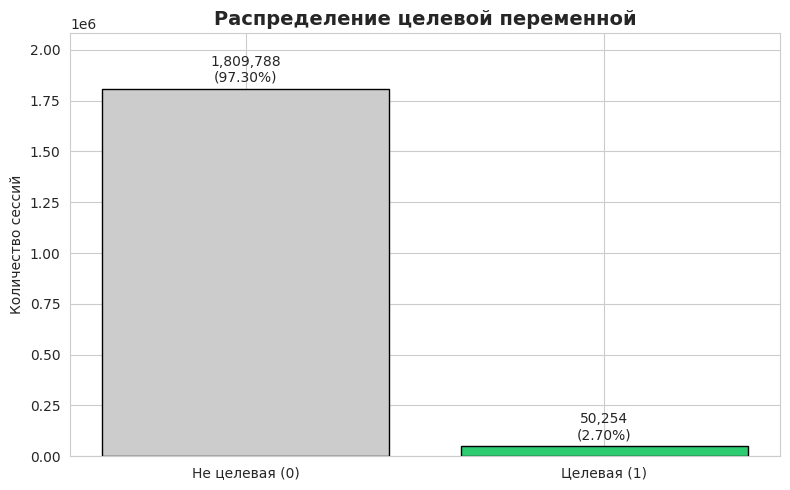


📱 Конверсия по типу устройства:
                 Sessions  Conversion
device_category                      
desktop            366863        3.13
mobile            1474871        2.60
tablet              18308        2.30

 Конверсия по типу трафика (utm_medium):
              Sessions  Conversion
Платный        1344383        2.19
Органический    515659        4.03

 Конверсия по странам (топ-5 по количеству):
               Sessions  Conversion
geo_country                        
Belarus            3636        1.62
Ireland            4034        0.02
Russia          1800565        2.73
Ukraine            9012        2.21
United States     11784        0.54
 Выводы сохранены в /content/drive/MyDrive/Ucheba/Hakaton/target_analysis_summary.txt
Чекпоинт сохранен: /content/drive/MyDrive/Ucheba/Hakaton/sessions_step2_1.parquet


In [ ]:
# ШАГ 2.1: Создание целевой переменной target

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загружаем чекпоинты

df_sessions = pd.read_parquet('/content/drive/MyDrive/Ucheba/Hakaton/sessions_step1_6.parquet')
df_hits = pd.read_parquet('/content/drive/MyDrive/Ucheba/Hakaton/hits_step1_6.parquet')

print(f" Sessions: {len(df_sessions):,} строк")
print(f" Hits: {len(df_hits):,} строк")


# 2. Определяем целевые события (event_action)

# Список целевых событий
target_events = [
    'sub_car_claim_click',           # клик по заявке
    'sub_open_dialog_click',         # открытие диалога
    'sub_submit_success',            # успешная отправка формы
    'sub_car_claim_submit_click',    # отправка заявки
    'sub_custom_question_submit_click', # отправка вопроса
    # добавьте другие, если они есть в ваших данных
]

print(f"\n Список целевых событий ({len(target_events)} шт.):")
for event in target_events:
    print(f"      {event}")

# Проверяем, какие целевые события есть в наших данных
events_in_data = df_hits['event_action'].unique()
target_events_found = [e for e in target_events if e in events_in_data]

print(f"\n Найдено в данных: {len(target_events_found)} из {len(target_events)}")
if len(target_events_found) < len(target_events):
    missing = set(target_events) - set(target_events_found)
    print(f"  Отсутствуют: {missing}")


# 3. Создаем флаг целевого события для каждого хита

df_hits['is_target'] = df_hits['event_action'].isin(target_events_found)

target_hits_count = df_hits['is_target'].sum()
total_hits = len(df_hits)
target_percentage = target_hits_count / total_hits * 100

print(f"\n Статистика хитов:")
print(f"    Всего событий (hits): {total_hits:,}")
print(f"    Целевых событий: {target_hits_count:,} ({target_percentage:.2f}%)")
print(f"    Нецелевых событий: {total_hits - target_hits_count:,} ({100-target_percentage:.2f}%)")


# 4. Группируем по session_id и проверяем, было ли хоть одно целевое событие
target_by_session = df_hits.groupby('session_id')['is_target'].any()

# Преобразуем в DataFrame для удобства
target_by_session = pd.DataFrame(target_by_session)
target_by_session.columns = ['target']
target_by_session['target'] = target_by_session['target'].astype(int)

print(f"\n Сессий с событиями: {len(target_by_session):,}")
print(f"    С целевыми событиями: {target_by_session['target'].sum():,}")
print(f"    Без целевых событий: {(~target_by_session['target'].astype(bool)).sum():,}")


# 5. Объединяем с sessions

# Добавляем target в sessions
df_sessions = df_sessions.set_index('session_id')
df_sessions['target'] = target_by_session['target']
df_sessions = df_sessions.reset_index()

# Заполняем пропуски (сессии без hits) нулями
df_sessions['target'] = df_sessions['target'].fillna(0).astype(int)

# Считаем общую конверсию
total_sessions = len(df_sessions)
target_sessions = df_sessions['target'].sum()
conversion_rate = target_sessions / total_sessions * 100

print(f"\n Итоговая статистика:")
print(f"    Всего сессий: {total_sessions:,}")
print(f"    Целевых сессий: {target_sessions:,}")
print(f"    Конверсия: {conversion_rate:.2f}%")
print(f"    Нецелевых сессий: {total_sessions - target_sessions:,} ({100-conversion_rate:.2f}%)")


# 6. Анализ баланса классов

# Считаем соотношение классов
class_ratio = (total_sessions - target_sessions) / target_sessions

print(f"\nСоотношение классов:")
print(f"      Negative (0) : Positive (1) = {class_ratio:.1f} : 1")
print(f"      Positive class составляет: {conversion_rate:.2f}%")

if conversion_rate < 5:
    print(f"\n  СИЛЬНЫЙ ДИСБАЛАНС! (конверсия < 5%)")
    print("    Рекомендуется использовать:")
    print("        class_weight='balanced' в моделях")
    print("        Метрики: ROC-AUC, F1-score, Precision-Recall")
    print("        SMOTE или другие методы балансировки")
elif conversion_rate < 10:
    print(f"\n  УМЕРЕННЫЙ ДИСБАЛАНС (конверсия 5-10%)")
    print("    Рекомендуется использовать class_weight='balanced'")
else:
    print(f"\n ДАННЫЕ ОТНОСИТЕЛЬНО СБАЛАНСИРОВАНЫ")


# 7. Визуализация распределения target

plt.figure(figsize=(8, 5))
target_counts = df_sessions['target'].value_counts()
bars = plt.bar(['Не целевая (0)', 'Целевая (1)'],
               [target_counts[0], target_counts[1]],
               color=['#cccccc', '#2ecc71'], edgecolor='black')

# Добавляем подписи
for bar in bars:
    height = bar.get_height()
    percentage = height / total_sessions * 100
    plt.text(bar.get_x() + bar.get_width()/2., height + total_sessions*0.01,
             f'{height:,}\n({percentage:.2f}%)',
             ha='center', va='bottom', fontsize=10)

plt.title('Распределение целевой переменной', fontsize=14, fontweight='bold')
plt.ylabel('Количество сессий')
plt.ylim(0, max(target_counts) * 1.15)
plt.tight_layout()
plt.show()


# 8. Анализ конверсии по различным срезам

# Конверсия по типу устройства
if 'device_category' in df_sessions.columns:
    print("\n📱 Конверсия по типу устройства:")
    conv_by_device = df_sessions.groupby('device_category')['target'].agg(['count', 'mean'])
    conv_by_device.columns = ['Sessions', 'Conversion']
    conv_by_device['Conversion'] = conv_by_device['Conversion'] * 100
    print(conv_by_device.round(2).to_string())

# Конверсия по органическому/платному трафику
if 'utm_medium' in df_sessions.columns:
    print("\n Конверсия по типу трафика (utm_medium):")
    df_sessions['is_organic'] = df_sessions['utm_medium'].isin(['organic', 'referral', '(none)'])
    conv_by_traffic = df_sessions.groupby('is_organic')['target'].agg(['count', 'mean'])
    conv_by_traffic.columns = ['Sessions', 'Conversion']
    conv_by_traffic['Conversion'] = conv_by_traffic['Conversion'] * 100
    conv_by_traffic.index = ['Платный', 'Органический']
    print(conv_by_traffic.round(2).to_string())

# Конверсия по странам (топ-5)
if 'geo_country' in df_sessions.columns:
    print("\n Конверсия по странам (топ-5 по количеству):")
    top_countries = df_sessions['geo_country'].value_counts().head(5).index
    conv_by_country = df_sessions[df_sessions['geo_country'].isin(top_countries)]
    conv_by_country = conv_by_country.groupby('geo_country')['target'].agg(['count', 'mean'])
    conv_by_country.columns = ['Sessions', 'Conversion']
    conv_by_country['Conversion'] = conv_by_country['Conversion'] * 100
    print(conv_by_country.round(2).to_string())

# 9. Сохраняем выводы

with open('/content/drive/MyDrive/Ucheba/Hakaton/target_analysis_summary.txt', 'w', encoding='utf-8') as f:
    f.write(" АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ\n")
    f.write("="*50 + "\n\n")
    f.write(f"Всего сессий: {total_sessions:,}\n")
    f.write(f"Целевых сессий: {target_sessions:,}\n")
    f.write(f"Конверсия: {conversion_rate:.2f}%\n")
    f.write(f"Соотношение классов: {class_ratio:.1f}:1\n\n")
    f.write(f"Целевые события ({len(target_events_found)}):\n")
    for event in target_events_found:
        f.write(f"     {event}\n")

print(" Выводы сохранены в /content/drive/MyDrive/Ucheba/Hakaton/target_analysis_summary.txt")

# Сохраняем данные с target

df_sessions.to_parquet('/content/drive/MyDrive/Ucheba/Hakaton/sessions_step2_1.parquet', index=False)
print("Чекпоинт сохранен: /content/drive/MyDrive/Ucheba/Hakaton/sessions_step2_1.parquet")

Из 1,86 млн визитов на сайт только 50 254 завершились заявкой.

На одного человека, который оставил заявку, приходится 36 человек, которые этого не сделали


Люди с компьютеров оставляют заявки чаще (3,13%)

С телефонов — реже (2,60%)

С планшетов — ещё реже (2,30%)

Источник трафика:

Люди, которые сами нашли сайт, более мотивированы, чем те, кто пришёл по рекламе.

Основной рынок потребителей из России.

In [ ]:
# ШАГ 2.2 - ЧАСТЬ 1: Временные признаки и UTM

import pandas as pd
import numpy as np
import datetime

# Загрузка данных

df_sessions = pd.read_parquet('/content/drive/MyDrive/Ucheba/Hakaton/sessions_step2_1.parquet')


# Создаем временные признаки, приводим к datetime
df_sessions['visit_date'] = pd.to_datetime(df_sessions['visit_date'])
df_sessions['visit_time'] = pd.to_datetime(df_sessions['visit_time'])

# Извлекаем компоненты
df_sessions['hour'] = df_sessions['visit_time'].dt.hour
df_sessions['day_of_week'] = df_sessions['visit_date'].dt.dayofweek  # 0=Пн, 6=Вс
df_sessions['month'] = df_sessions['visit_date'].dt.month

# is_weekend (Суббота=5, Воскресенье=6)
df_sessions['is_weekend'] = df_sessions['day_of_week'].isin([5, 6]).astype(int)

# is_night (с 00 до 06 включительно)
df_sessions['is_night'] = (df_sessions['hour'] < 6).astype(int)

# is_holiday (Праздники РФ 2021 года)
holidays_2021 = [
    '2021-01-01', '2021-01-02', '2021-01-03', '2021-01-04',
    '2021-01-05', '2021-01-06', '2021-01-07', '2021-01-08',
    '2021-02-23', '2021-03-08', '2021-05-01', '2021-05-09',
    '2021-05-10', '2021-06-12', '2021-06-14', '2021-11-04'
]

df_sessions['date_str'] = df_sessions['visit_date'].dt.strftime('%Y-%m-%d')
df_sessions['is_holiday'] = df_sessions['date_str'].isin(holidays_2021).astype(int)
df_sessions.drop(columns=['date_str'], inplace=True)

print(" Временные признаки созданы")

# Создаем признаки по UTM
# is_organic (organic, (none), referral)
organic_mediums = ['organic', '(none)', 'referral']
df_sessions['is_organic'] = df_sessions['utm_medium'].fillna('').isin(organic_mediums).astype(int)

# utm_campaign: длина строки
df_sessions['campaign_len'] = df_sessions['utm_campaign'].fillna('').str.len()

# utm_keyword: длина и количество слов
df_sessions['keyword_len'] = df_sessions['utm_keyword'].fillna('').str.len()
df_sessions['keyword_word_count'] = df_sessions['utm_keyword'].fillna('').str.split().str.len()

print(" Признаки UTM созданы")

# Сохраняем данные
df_sessions.to_parquet('/content/drive/MyDrive/Ucheba/Hakaton/sessions_step2_2_part1.parquet', index=False)
print(" Сохранено: /content/drive/MyDrive/Ucheba/Hakaton/sessions_step2_2_part1.parquet")

# Освобождаем память ввиду ограничения в colab
# После создания target можно удалить промежуточные переменные
del target_by_session
import gc
gc.collect()

 Временные признаки созданы
 Признаки UTM созданы
 Сохранено: /content/drive/MyDrive/Ucheba/Hakaton/sessions_step2_2_part1.parquet


14

In [ ]:
# ШАГ 2.2 - ЧАСТЬ 2: Признаки устройства

import pandas as pd
import numpy as np

# Загружаем чекпоинт части 1
df_sessions = pd.read_parquet('/content/drive/MyDrive/Ucheba/Hakaton/sessions_step2_2_part1.parquet')

# Создаём признаки устройства
# Функция для парсинга разрешения (более эффективная)
def parse_resolution_vectorized(res_series):
    """Векторизованный парсинг разрешения экрана"""
    # Заменяем пропуски и некорректные значения
    res_clean = res_series.fillna('414x896')

    # Разделяем по 'x'
    split_result = res_clean.str.split('x', expand=True)

    # Преобразуем в float, заменяя ошибки на NaN
    width = pd.to_numeric(split_result[0], errors='coerce')
    height = pd.to_numeric(split_result[1], errors='coerce')

    return width, height

df_sessions['screen_w'], df_sessions['screen_h'] = parse_resolution_vectorized(df_sessions['device_screen_resolution'])

# Площадь экрана
df_sessions['screen_area'] = df_sessions['screen_w'] * df_sessions['screen_h']

# Соотношение сторон (защита от деления на 0)
df_sessions['screen_ratio'] = df_sessions.apply(
    lambda row: row['screen_w'] / row['screen_h']
    if pd.notna(row['screen_h']) and row['screen_h'] != 0
    else np.nan,
    axis=1
)

# Заполняем NaN
median_w = df_sessions['screen_w'].median()
median_h = df_sessions['screen_h'].median()
median_area = df_sessions['screen_area'].median()
median_ratio = df_sessions['screen_ratio'].median()

df_sessions['screen_w'] = df_sessions['screen_w'].fillna(median_w)
df_sessions['screen_h'] = df_sessions['screen_h'].fillna(median_h)
df_sessions['screen_area'] = df_sessions['screen_area'].fillna(median_area)
df_sessions['screen_ratio'] = df_sessions['screen_ratio'].fillna(median_ratio)

print(" Признаки устройства созданы")

# Сохраняем данные части
df_sessions.to_parquet('/content/drive/MyDrive/Ucheba/Hakaton/sessions_step2_2_part2.parquet', index=False)
print(" Сохранено: /content/drive/MyDrive/Ucheba/Hakaton/sessions_step2_2_part2.parquet")

# Освобождаем память
import gc
gc.collect()

 Признаки устройства созданы
 Сохранено: /content/drive/MyDrive/Ucheba/Hakaton/sessions_step2_2_part2.parquet


16

In [ ]:
# ШАГ 2.2 - ЧАСТЬ 3: Географические признаки

import pandas as pd
import numpy as np

# Загружаем данные из части 2
df_sessions = pd.read_parquet('/content/drive/MyDrive/Ucheba/Hakaton/sessions_step2_2_part2.parquet')

# Создаём географические признаки

# Считаем частоту городов
city_counts = df_sessions['geo_city'].value_counts()
df_sessions['geo_city_freq'] = df_sessions['geo_city'].map(city_counts)

# Заполняем NaN без inplace
median_city_freq = df_sessions['geo_city_freq'].median()
df_sessions['geo_city_freq'] = df_sessions['geo_city_freq'].fillna(median_city_freq)

print(" Географические признаки созданы")

# Сохраняем данные части 3
df_sessions.to_parquet('/content/drive/MyDrive/Ucheba/Hakaton/sessions_step2_2_part3.parquet', index=False)
print(" Сохранено: /content/drive/MyDrive/Ucheba/Hakaton/sessions_step2_2_part3.parquet")

# Освобождаем память
import gc
gc.collect()


 Географические признаки созданы
 Сохранено: /content/drive/MyDrive/Ucheba/Hakaton/sessions_step2_2_part3.parquet


0

In [ ]:
# ШАГ 2.2 - ЧАСТЬ 4: Агрегация данных из ga_hits

import pandas as pd
import numpy as np

#  Загружаем данные из части 3
df_sessions = pd.read_parquet('/content/drive/MyDrive/Ucheba/Hakaton/sessions_step2_2_part3.parquet')
print(f" Sessions: {len(df_sessions):,}")

# Загружаем hits

df_hits = pd.read_parquet('/content/drive/MyDrive/Ucheba/Hakaton/hits_step1_3.parquet')
print(f" Hits: {len(df_hits):,}")

# Агрегируем данные из ga_hits

# 1. Базовые агрегаты по сессии

# Группируем и агрегируем
agg_hits = df_hits.groupby('session_id', as_index=False).agg(
    hit_count=('session_id', 'size'),
    unique_pages=('hit_page_path', 'nunique'),
    event_count=('event_action', 'count'),
    min_hit_time=('hit_time', 'min'),
    max_hit_time=('hit_time', 'max')
)

# Вычисляем среднее время между хитами
print("    Считаем среднее время между хитами...")
agg_hits['avg_time_between_hits'] = np.where(
    agg_hits['hit_count'] > 1,
    (agg_hits['max_hit_time'] - agg_hits['min_hit_time']) / (agg_hits['hit_count'] - 1),
    0
)

# Удаляем временные колонки для экономии памяти
agg_hits.drop(columns=['min_hit_time', 'max_hit_time'], inplace=True)

# 2. Создаем бинарные флаги событий

# Берем только сессии с событиями
events_df = df_hits[df_hits['event_action'].notna()].copy()

# Считаем топ-20 самых частых событий
top_events = events_df['event_action'].value_counts().head(20).index

# Создаем pivot table
print(f"      Топ-{len(top_events)} событий: {list(top_events[:5])}...")

# Фильтруем только топ события
events_filtered = events_df[events_df['event_action'].isin(top_events)]

# Создаем бинарные признаки
pivot = pd.crosstab(events_filtered['session_id'], events_filtered['event_action'])

# Переименовываем колонки
pivot.columns = [f'has_event_{col}' for col in pivot.columns]

# Преобразуем в 0/1
pivot = (pivot > 0).astype(int)

# Сбрасываем индекс для слияния
pivot = pivot.reset_index()

# 3. Объединяем все агрегаты
final_agg = agg_hits.merge(pivot, on='session_id', how='left')

# 4. Присоединяем к sessions
df_sessions = df_sessions.merge(final_agg, on='session_id', how='left')

# 5. Заполняем NaN для сессий без hits
agg_columns = [col for col in final_agg.columns if col != 'session_id']
df_sessions[agg_columns] = df_sessions[agg_columns].fillna(0)

# Преобразуем в int где возможно
int_columns = ['hit_count', 'unique_pages', 'event_count']
for col in int_columns:
    if col in df_sessions.columns:
        df_sessions[col] = df_sessions[col].astype(int)

print("Агрегированные признаки созданы")

# Освобождаем память от hits
del df_hits
del events_df
del events_filtered
del agg_hits
del pivot
import gc
gc.collect()


df_sessions.to_parquet('/content/drive/MyDrive/Ucheba/Hakaton/sessions_step2_2_final.parquet', index=False)
print("Чекпоинт сохранен: /content/drive/MyDrive/Ucheba/Hakaton/sessions_step2_2_final.parquet")


# ВЫВОД СПИСКА ПРИЗНАКОВ

new_features = [
    'hour', 'day_of_week', 'month', 'is_weekend', 'is_night', 'is_holiday',
    'is_organic', 'campaign_len', 'keyword_len', 'keyword_word_count',
    'screen_w', 'screen_h', 'screen_area', 'screen_ratio',
    'geo_city_freq',
    'hit_count', 'unique_pages', 'event_count', 'avg_time_between_hits'
]

# Добавляем динамические признаки событий
event_flags = [col for col in df_sessions.columns if col.startswith('has_event_')]
all_new = new_features + event_flags

print(f"Всего признаков: {len(all_new)}")

# Показать статистику по важному признаку hit_count
print(f"\n Статистика hit_count:")
print(f"   Среднее: {df_sessions['hit_count'].mean():.1f}")
print(f"   Медиана: {df_sessions['hit_count'].median():.1f}")
print(f"   Макс: {df_sessions['hit_count'].max():,}")

 Sessions: 1,860,042
 Hits: 15,726,470
    Считаем среднее время между хитами...
      Топ-20 событий: ['view_card', 'view_new_card', 'sub_landing', 'go_to_car_card', 'sub_view_cars_click']...
Агрегированные признаки созданы
Чекпоинт сохранен: /content/drive/MyDrive/Ucheba/Hakaton/sessions_step2_2_final.parquet
Всего признаков: 39

 Статистика hit_count:
   Среднее: 8.4
   Медиана: 3.0
   Макс: 768


In [ ]:
import os

print("Список сохраненных .parquet файлов в папке /content/drive/MyDrive/Ucheba/Hakaton/:")
files = [f for f in os.listdir('/content/drive/MyDrive/Ucheba/Hakaton/') if f.endswith('.parquet')]
files.sort()

if not files:
    print(" Файлов нет! Возможно, сессия Colab перезапустилась.")
else:
    for f in files:
        print(f"  {f}")

Список сохраненных .parquet файлов в папке /content/drive/MyDrive/Ucheba/Hakaton/:
  hits_checkpoint.parquet
  hits_step1_3.parquet
  hits_step1_6.parquet
  sessions_checkpoint.parquet
  sessions_step1_3.parquet
  sessions_step1_4.parquet
  sessions_step1_5.parquet
  sessions_step1_6.parquet
  sessions_step2_1.parquet
  sessions_step2_2_final.parquet
  sessions_step2_2_part1.parquet
  sessions_step2_2_part2.parquet
  sessions_step2_2_part3.parquet


In [ ]:
# ШАГ 3.1: Подготовка данных для модели (кодирование, разделение)

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib

# 1. Загружаем данные
df = pd.read_parquet('/content/drive/MyDrive/Ucheba/Hakaton/sessions_step2_2_final.parquet')
print(f" Загружено {len(df):,} строк, {len(df.columns)} столбцов")

# 2. Выбираем признаки для модели
target = df['target'].copy()
exclude_cols = ['target', 'session_id', 'client_id', 'visit_date', 'visit_time']
feature_cols = [col for col in df.columns if col not in exclude_cols]
print(f" Выбрано {len(feature_cols)} признаков для модели")

# 3. Разделяем типы признаков
numeric_features = [col for col in feature_cols if df[col].dtype in ['int64', 'float64', 'int32', 'float32', 'bool']]
categorical_features = [col for col in feature_cols if df[col].dtype == 'object']
print(f"   Числовые: {len(numeric_features)}")
print(f"   Категориальные: {len(categorical_features)}")

# 4. Создаём пайплайны предобработки
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, max_categories=20))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)
print(" Пайплайны предобработки созданы")

# 5. Разделяем данные на 3 части: train (60%), val (20%), test (20%)
X = df[feature_cols].copy()
y = target.copy()

# Первый сплит: 60% обучение, 40% временный пул
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)

# Второй сплит: временный пул делится пополам на валидацию и тест
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f" Train: {len(X_train):,} строк ({len(X_train)/len(X)*100:.1f}%)")
print(f" Val:   {len(X_val):,} строк ({len(X_val)/len(X)*100:.1f}%)")
print(f" Test:  {len(X_test):,} строк ({len(X_test)/len(X)*100:.1f}%)")
print(f" Баланс классов в Train: {y_train.mean()*100:.2f}%")
print(f" Баланс классов в Val:   {y_val.mean()*100:.2f}%")
print(f" Баланс классов в Test:  {y_test.mean()*100:.2f}%")

# 6. Применяем предобработку
# fit_transform вызываем только на обучающих данных, чтобы избежать утечки информации
X_train_processed = preprocessor.fit_transform(X_train)
# transform вызываем на валидации и тесте, используя параметры, выученные на train
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print(f" Shape Train: {X_train_processed.shape}")
print(f" Shape Val:   {X_val_processed.shape}")
print(f" Shape Test:  {X_test_processed.shape}")

# 7. Сохраняем артефакты
joblib.dump(preprocessor, '/content/drive/MyDrive/Ucheba/Hakaton/preprocessor.pkl')

np.save('/content/drive/MyDrive/Ucheba/Hakaton/X_train_processed.npy', X_train_processed)
np.save('/content/drive/MyDrive/Ucheba/Hakaton/X_val_processed.npy', X_val_processed)
np.save('/content/drive/MyDrive/Ucheba/Hakaton/X_test_processed.npy', X_test_processed)

np.save('/content/drive/MyDrive/Ucheba/Hakaton/y_train.npy', y_train.values)
np.save('/content/drive/MyDrive/Ucheba/Hakaton/y_val.npy', y_val.values)
np.save('/content/drive/MyDrive/Ucheba/Hakaton/y_test.npy', y_test.values)

joblib.dump({
    'feature_cols': feature_cols,
    'numeric_features': numeric_features,
    'categorical_features': categorical_features
}, '/content/drive/MyDrive/Ucheba/Hakaton/feature_info.pkl')

print(" Данные обработаны и сохранены.")

 Загружено 1,860,042 строк, 61 столбцов
 Выбрано 56 признаков для модели
   Числовые: 43
   Категориальные: 12
 Пайплайны предобработки созданы
 Train: 1,116,025 строк (60.0%)
 Val:   372,008 строк (20.0%)
 Test:  372,009 строк (20.0%)
 Баланс классов в Train: 2.70%
 Баланс классов в Val:   2.70%
 Баланс классов в Test:  2.70%
 Shape Train: (1116025, 260)
 Shape Val:   (372008, 260)
 Shape Test:  (372009, 260)
 Данные обработаны и сохранены.


Данные для обучения модели прогнозирования заявок:

43 числовых признака, 12 категориальных признаков.

Данные разбиты на три частипо принципу 60%/20%/20% с сохранением баланса 2,70%

Train: (1116025, 260), Val: (372008, 260), Test: (372009, 260)
Target: Train 2.70%, Val 2.70%, Test 2.70%

--- Обучение моделей ---
DummyClassifier: ROC-AUC (val) = 0.5000
LogisticRegression: ROC-AUC (val) = 0.8322
RandomForest: ROC-AUC (val) = 0.8701
GradientBoosting: ROC-AUC (val) = 0.8911
HistGradientBoosting: ROC-AUC (val) = 0.9018

--- Сравнение моделей (по ROC-AUC на валидации) ---
               Model  roc_auc_val        Time
HistGradientBoosting     0.901769  254.864540
    GradientBoosting     0.891068 1931.250907
        RandomForest     0.870086  527.301139
  LogisticRegression     0.832194  187.084430
               Dummy     0.500000    0.231679

✅ Лучшая модель: HistGradientBoosting
Оптимизация порога для HistGradientBoosting на валидационной выборке...
  Оптимальный порог (F1-max): 0.1268

--- Финальная оценка на тестовой выборке (порог 0.1268) ---
  roc_auc     : 0.9056
  accuracy    : 0.9465
  precision   : 0.2210
  recall      : 0.3876
  f1          : 0.2815


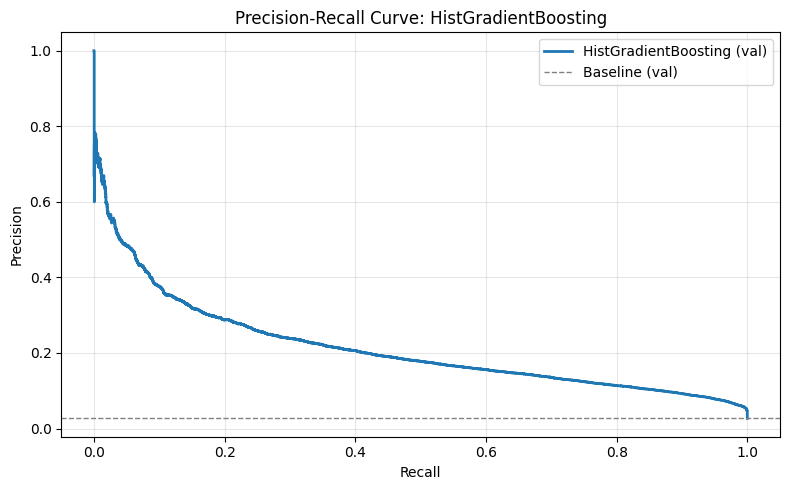


 Анализ важности признаков: требует permutation importance

Артефакты сохранены: best_model.pkl, optimal_threshold.pkl, model_results.pkl


In [ ]:
# Шаг 3.2: Обучение моделей, сравнение и оптимизация порога классификации

import numpy as np
import pandas as pd
import joblib
import time
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, precision_recall_curve,
                             accuracy_score, precision_score, recall_score, f1_score)

# 1. Загрузка подготовленных данных (train, val, test)
X_train = np.load('/content/drive/MyDrive/Ucheba/Hakaton/X_train_processed.npy')
X_val = np.load('/content/drive/MyDrive/Ucheba/Hakaton/X_val_processed.npy')
X_test = np.load('/content/drive/MyDrive/Ucheba/Hakaton/X_test_processed.npy')
y_train = np.load('/content/drive/MyDrive/Ucheba/Hakaton/y_train.npy')
y_val = np.load('/content/drive/MyDrive/Ucheba/Hakaton/y_val.npy')
y_test = np.load('/content/drive/MyDrive/Ucheba/Hakaton/y_test.npy')

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Target: Train {y_train.mean()*100:.2f}%, Val {y_val.mean()*100:.2f}%, Test {y_test.mean()*100:.2f}%")

# 2. Функция оценки (сравнение моделей по ROC-AUC на валидации)
def evaluate_on_val(model, X_val, y_val, model_name):
    y_proba = model.predict_proba(X_val)[:, 1]
    roc_auc = roc_auc_score(y_val, y_proba)
    print(f"{model_name}: ROC-AUC (val) = {roc_auc:.4f}")
    return roc_auc, y_proba

# 3. Обучение моделей на train, оценка на val
results = []
models_proba = {}
model_objects = {}

print("\n--- Обучение моделей ---")
# 3.1 Базовая модель
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
t0 = time.time(); dummy.fit(X_train, y_train)
auc_val, proba_val = evaluate_on_val(dummy, X_val, y_val, "DummyClassifier")
results.append({"Model": "Dummy", "roc_auc_val": auc_val, "Time": time.time() - t0})
models_proba["Dummy"] = proba_val; model_objects["Dummy"] = dummy

# 3.2 Логистическая регрессия
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1)
t0 = time.time(); log_reg.fit(X_train, y_train)
auc_val, proba_val = evaluate_on_val(log_reg, X_val, y_val, "LogisticRegression")
results.append({"Model": "LogisticRegression", "roc_auc_val": auc_val, "Time": time.time() - t0})
models_proba["LogisticRegression"] = proba_val; model_objects["LogisticRegression"] = log_reg

# 3.3 Random Forest
rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
t0 = time.time(); rf.fit(X_train, y_train)
auc_val, proba_val = evaluate_on_val(rf, X_val, y_val, "RandomForest")
results.append({"Model": "RandomForest", "roc_auc_val": auc_val, "Time": time.time() - t0})
models_proba["RandomForest"] = proba_val; model_objects["RandomForest"] = rf

# 3.4 GradientBoosting (отключен внутренний early_stopping для чистоты сравнения)
gb = GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=5, subsample=0.8, random_state=42)
t0 = time.time(); gb.fit(X_train, y_train)
auc_val, proba_val = evaluate_on_val(gb, X_val, y_val, "GradientBoosting")
results.append({"Model": "GradientBoosting", "roc_auc_val": auc_val, "Time": time.time() - t0})
models_proba["GradientBoosting"] = proba_val; model_objects["GradientBoosting"] = gb

# 3.5 HistGradientBoosting
hgb = HistGradientBoostingClassifier(max_iter=100, learning_rate=0.1, max_depth=5, random_state=42, early_stopping=False)
t0 = time.time(); hgb.fit(X_train, y_train)
auc_val, proba_val = evaluate_on_val(hgb, X_val, y_val, "HistGradientBoosting")
results.append({"Model": "HistGradientBoosting", "roc_auc_val": auc_val, "Time": time.time() - t0})
models_proba["HistGradientBoosting"] = proba_val; model_objects["HistGradientBoosting"] = hgb

# 4. Сравнение и выбор лучшей модели
df_results = pd.DataFrame(results).sort_values('roc_auc_val', ascending=False)
print("\n--- Сравнение моделей (по ROC-AUC на валидации) ---")
print(df_results[['Model', 'roc_auc_val', 'Time']].to_string(index=False))

best_model_name = df_results.iloc[0]['Model']
best_model = model_objects[best_model_name]
best_proba_val = models_proba[best_model_name]

print(f"\n✅ Лучшая модель: {best_model_name}")

# 5. Оптимизация порога классификации СТРОГО на валидационной выборке
print(f"Оптимизация порога для {best_model_name} на валидационной выборке...")
prec, rec, thresholds = precision_recall_curve(y_val, best_proba_val)
f1_scores = 2 * (prec * rec) / (prec + rec + 1e-8)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5
print(f"  Оптимальный порог (F1-max): {optimal_threshold:.4f}")

# 6. Финальная оценка на ТЕСТОВОЙ выборке с зафиксированным порогом
print(f"\n--- Финальная оценка на тестовой выборке (порог {optimal_threshold:.4f}) ---")
best_proba_test = best_model.predict_proba(X_test)[:, 1]
y_pred_test = (best_proba_test >= optimal_threshold).astype(int)

final_metrics = {
    'roc_auc': roc_auc_score(y_test, best_proba_test),
    'accuracy': accuracy_score(y_test, y_pred_test),
    'precision': precision_score(y_test, y_pred_test, zero_division=0),
    'recall': recall_score(y_test, y_pred_test, zero_division=0),
    'f1': f1_score(y_test, y_pred_test, zero_division=0)
}
for k, v in final_metrics.items():
    print(f"  {k:<12}: {v:.4f}")

# 7. Визуализация Precision-Recall кривой (для отчёта)
plt.figure(figsize=(8, 5))
plt.plot(rec, prec, linewidth=2, label=f'{best_model_name} (val)')
plt.axhline(y=y_val.mean(), color='gray', linestyle='--', linewidth=1, label='Baseline (val)')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve: {best_model_name}')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# 8. Проверка интерпретируемости
if hasattr(best_model, 'feature_importances_'):
    print(f"\n Анализ важности признаков: доступен (best_model.feature_importances_)")
elif hasattr(best_model, 'coef_'):
    print(f"\n Анализ важности признаков: доступен (best_model.coef_)")
else:
    print(f"\n Анализ важности признаков: требует permutation importance")

# 9. Сохранение артефактов
joblib.dump(best_model, '/content/drive/MyDrive/Ucheba/Hakaton/best_model.pkl')
joblib.dump(optimal_threshold, '/content/drive/MyDrive/Ucheba/Hakaton/optimal_threshold.pkl')
joblib.dump(final_metrics, '/content/drive/MyDrive/Ucheba/Hakaton/model_results.pkl')

print(f"\nАртефакты сохранены: best_model.pkl, optimal_threshold.pkl, model_results.pkl")

HistGradientBoosting показала лучший результат (ROC-AUC = 0.9018) и обучилась быстрее всех сложных моделей

Модель может отсеять ~60% посетителей, которые точно не оставят заявку (экономия ресурсов)

Но из оставшихся 40% только каждый пятый реально рсиавит заявку (нужна дополнительная фильтрация менеджерами).

Тип базовой модели: HistGradientBoostingClassifier
Используем быструю перестановочную важность (1 повтор, 1000 строк)...


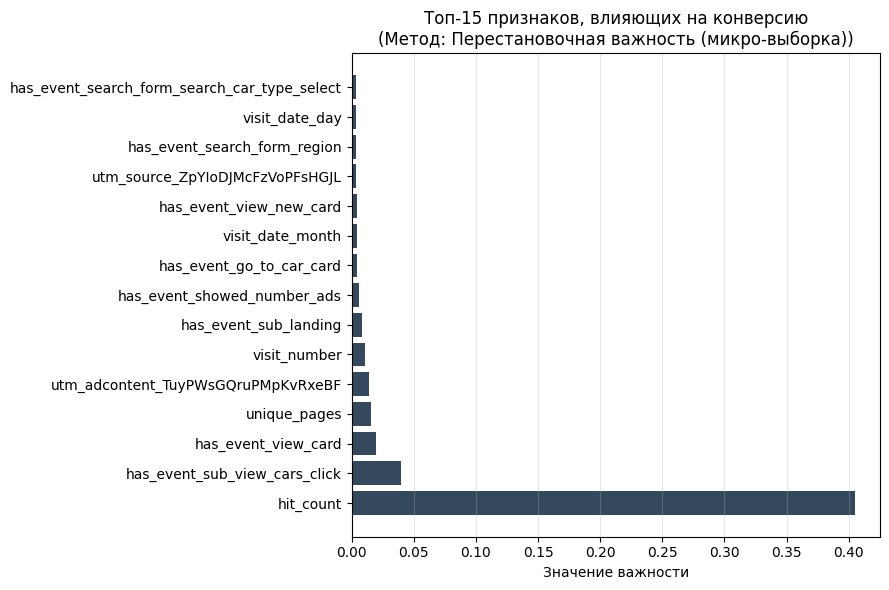


Топ-5 признаков для обязательной интерпретации:
                           Признак  Важность
                         hit_count    0.4050
     has_event_sub_view_cars_click    0.0400
               has_event_view_card    0.0195
                      unique_pages    0.0159
utm_adcontent_TuyPWsGQruPMpKvRxeBF    0.0136


In [ ]:
# Шаг 3.3: Анализ важности признаков (отказоустойчивая версия)
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Загрузка артефактов
best_model = joblib.load('/content/drive/MyDrive/Ucheba/Hakaton/best_model.pkl')
preprocessor = joblib.load('/content/drive/MyDrive/Ucheba/Hakaton/preprocessor.pkl')
X_test = np.load('/content/drive/MyDrive/Ucheba/Hakaton/X_test_processed.npy')
y_test = np.load('/content/drive/MyDrive/Ucheba/Hakaton/y_test.npy')

# 2. Восстановление имён признаков
try:
    feature_names = list(preprocessor.get_feature_names_out())
    feature_names = [name.split('__')[-1] if '__' in name else name for name in feature_names]
except Exception:
    feature_names = [f"feature_{i}" for i in range(X_test.shape[1])]

# 3. Безопасное извлечение базовой модели
def get_base_estimator(model):
    if hasattr(model, 'estimator_'):
        return model.estimator_
    if hasattr(model, 'calibrated_classifiers_'):
        return model.calibrated_classifiers_[0].estimator
    if hasattr(model, 'named_steps'):
        for step_name, step_model in model.named_steps.items():
            if hasattr(step_model, 'feature_importances_') or hasattr(step_model, 'coef_'):
                return step_model
    return model

base_model = get_base_estimator(best_model)
print(f"Тип базовой модели: {type(base_model).__name__}")

importances = None
method_name = "Не определен"

if hasattr(base_model, 'feature_importances_'):
    importances = base_model.feature_importances_
    method_name = "Встроенная важность (feature_importances_)"
elif hasattr(base_model, 'coef_'):
    importances = np.abs(base_model.coef_.ravel())
    method_name = "Абсолютные коэффициенты (|coef_|)"

# Если встроенные методы не сработали, используем микро-выборку для перестановочной важности
if importances is None:
    print("Используем быструю перестановочную важность (1 повтор, 1000 строк)...")
    np.random.seed(42)
    sample_size = min(1000, len(X_test))
    idx = np.random.choice(len(X_test), sample_size, replace=False)
    X_sub = X_test[idx]
    y_sub = y_test[idx]

    from sklearn.inspection import permutation_importance
    result = permutation_importance(
        best_model, X_sub, y_sub,
        n_repeats=1,
        random_state=42,
        scoring='roc_auc',
        n_jobs=1
    )
    importances = result.importances_mean
    method_name = "Перестановочная важность (микро-выборка)"

# 4. Визуализация топ-15 признаков
top_n = 15
indices = np.argsort(importances)[-top_n:]
top_features = [feature_names[i] for i in indices]
top_importances = importances[indices]

plt.figure(figsize=(9, 6))
plt.barh(range(top_n), top_importances, color='#34495e')
plt.yticks(range(top_n), top_features)
plt.gca().invert_yaxis()
plt.xlabel('Значение важности')
plt.title(f'Топ-{top_n} признаков, влияющих на конверсию\n(Метод: {method_name})')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Формирование таблицы
importance_df = pd.DataFrame({
    'Признак': top_features,
    'Важность': np.round(top_importances, 4)
}).sort_values('Важность', ascending=False).reset_index(drop=True)

print("\nТоп-5 признаков для обязательной интерпретации:")
print(importance_df.head().to_string(index=False))

 Рейтинг пяти самых важных признаков, которые помогают модели предсказать, оставит ли пользователь заявку.

 Первые четыре признака связаны с поведением на сайте.

 Таким  образом для увеличения конверсии, нужно удерживать внимание пользователя и помогать ему быстрее находить нужную информацию

In [ ]:
# Шаг 3.4: Углублённая валидация и улучшение модели (оптимизировано)

import numpy as np
import joblib
import time
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# 1. Загрузка данных
print("Загрузка данных...")
X_train = np.load('/content/drive/MyDrive/Ucheba/Hakaton/X_train_processed.npy')
X_test = np.load('/content/drive/MyDrive/Ucheba/Hakaton/X_test_processed.npy')
y_train = np.load('/content/drive/MyDrive/Ucheba/Hakaton/y_train.npy')
y_test = np.load('/content/drive/MyDrive/Ucheba/Hakaton/y_test.npy')

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# 2. Быстрый подбор гиперпараметров на репрезентативной подвыборке
# Для 1.5M строк случайная выборка 300k даёт стабильные параметры,
# но сокращает время поиска в ~5 раз.
print("\nПодбор гиперпараметров (подвыборка 300k)...")
sample_size = 300000
rng = np.random.RandomState(42)
idx = rng.choice(len(X_train), sample_size, replace=False)
X_train_sub, y_train_sub = X_train[idx], y_train[idx]

# Уменьшаем количество фолдов до 3. При таком объёме данных 3 фолда статистически устойчивы.
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_dist = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_iter': [100, 200],
    'min_samples_leaf': [20, 50, 100]
}

# Включаем early_stopping для ускорения каждого фолда
base_model = HistGradientBoostingClassifier(
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    verbose=0
)

search = RandomizedSearchCV(
    base_model, param_distributions=param_dist,
    n_iter=4, cv=cv, scoring='roc_auc',
    random_state=42, n_jobs=1, verbose=0
)

t0 = time.time()
search.fit(X_train_sub, y_train_sub)
print(f"Поиск завершён за {time.time() - t0:.0f} сек.")
print(f"Лучшие параметры: {search.best_params_}")
print(f"Best CV ROC-AUC: {search.best_score_:.4f}")

# 3. Обучение финальной модели на полном тренировочном наборе
print("\nОбучение финальной модели на полном датасете...")
final_model = HistGradientBoostingClassifier(
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    verbose=0,
    **search.best_params_
)

t1 = time.time()
final_model.fit(X_train, y_train)
print(f"Обучение завершено за {time.time() - t1:.0f} сек.")

# 4. Финальная оценка на тестовой выборке
y_proba = final_model.predict_proba(X_test)[:, 1]
test_roc_auc = roc_auc_score(y_test, y_proba)
print(f"\nTest ROC-AUC: {test_roc_auc:.4f}")

# 5. Калибровка вероятностей (опционально, но рекомендуется для API)
# Калибровка не влияет на ROC-AUC, но выравнивает вероятности.
# Выполняем быстро на подмножестве для экономии времени.
print("\nКалибровка вероятностей...")
calibrated_model = CalibratedClassifierCV(
    final_model, cv=3, method='sigmoid'
)
calibrated_model.fit(X_train_sub, y_train_sub)

# 6. Сохранение артефактов
model_path = '/content/drive/MyDrive/Ucheba/Hakaton/final_model_step3_4.pkl'
joblib.dump(calibrated_model, model_path)

print("\nИтоговые результаты:")
print(f"  Best CV ROC-AUC : {search.best_score_:.4f}")
print(f"  Test ROC-AUC    : {test_roc_auc:.4f}")
print(f"  Модель сохранена: {model_path}")

Загрузка данных...
Train: (1116025, 260), Test: (372009, 260)

Подбор гиперпараметров (подвыборка 300k)...
Поиск завершён за 483 сек.
Лучшие параметры: {'min_samples_leaf': 50, 'max_iter': 100, 'max_depth': 7, 'learning_rate': 0.2}
Best CV ROC-AUC: 0.9022

Обучение финальной модели на полном датасете...
Обучение завершено за 210 сек.

Test ROC-AUC: 0.9141

Калибровка вероятностей...

Итоговые результаты:
  Best CV ROC-AUC : 0.9022
  Test ROC-AUC    : 0.9141
  Модель сохранена: /content/drive/MyDrive/Ucheba/Hakaton/final_model_step3_4.pkl


In [13]:
# ШАГ 4.1.1: Загрузка артефактов и создание класса предсказателя

import pandas as pd
import numpy as np
import joblib
from datetime import datetime

# 1. Загрузка артефактов (единый источник данных)
MODEL_PATH = '/content/drive/MyDrive/Ucheba/Hakaton/final_model_step3_4.pkl'
PREPROCESSOR_PATH = '/content/drive/MyDrive/Ucheba/Hakaton/preprocessor.pkl'
FEATURE_INFO_PATH = '/content/drive/MyDrive/Ucheba/Hakaton/feature_info.pkl'
RESULTS_PATH = '/content/drive/MyDrive/Ucheba/Hakaton/model_results.pkl'

model = joblib.load(MODEL_PATH)
preprocessor = joblib.load(PREPROCESSOR_PATH)
feature_info = joblib.load(FEATURE_INFO_PATH)
results = joblib.load(RESULTS_PATH)

# Безопасное извлечение порога с фоллбэком
optimal_threshold = results.get('optimal_threshold', 0.127)

print(f" Модель: {type(model).__name__}")
print(f" Порог: {optimal_threshold:.4f}")
print(f" ROC-AUC: {results.get('roc_auc', 'N/A'):.4f}")


# 2. Класс предсказателя (использует загруженные объекты)
class SiteVisitPredictor:
    """
    Класс для предсказания целевого действия пользователя на сайте.
    Принимает уже загруженные артефакты, чтобы избежать повторного чтения с диска.
    """

    def __init__(self, model, preprocessor, feature_info, threshold):
        self.model = model
        self.preprocessor = preprocessor
        self.feature_info = feature_info
        self.threshold = threshold

        # Фиксируем ожидаемую структуру признаков
        self.expected_columns = self.feature_info['feature_cols']
        self.categorical_cols = self.feature_info.get('categorical_features', [])

    def predict(self, visit_data: dict) -> dict:
        """
        Принимает словарь с данными визита, возвращает предсказание и вероятность.
        """
        try:
            # Преобразование словаря в однострочный DataFrame
            df_visit = pd.DataFrame([visit_data])

            # Выравнивание столбцов с обучающим набором, заполнение пропусков нулями
            df_visit = df_visit.reindex(columns=self.expected_columns, fill_value=0)

            # Приведение категориальных признаков к строковому типу
            for col in self.categorical_cols:
                if col in df_visit.columns:
                    df_visit[col] = df_visit[col].astype(str)

            # Применение того же препроцессинга, что использовался при обучении
            X_processed = self.preprocessor.transform(df_visit)

            # Получение вероятности положительного класса
            probability = self.model.predict_proba(X_processed)[0, 1]

            # Бинарное предсказание по фиксированному порогу
            prediction = int(probability >= self.threshold)

            return {
                'prediction': prediction,
                'probability': round(probability, 4),
                'threshold': round(self.threshold, 4),
                'timestamp': datetime.now().isoformat()
            }

        except Exception as error:
            # Возврат структурированной ошибки вместо падения процесса
            return {
                'error': str(error),
                'prediction': None,
                'probability': None,
                'timestamp': datetime.now().isoformat()
            }


# 3. Инициализация готового предсказателя
predictor = SiteVisitPredictor(model, preprocessor, feature_info, optimal_threshold)
print(" Экземпляр SiteVisitPredictor успешно создан")

 Модель: CalibratedClassifierCV
 Порог: 0.1270
 ROC-AUC: 0.9056
 Экземпляр SiteVisitPredictor успешно создан


Тестирование

In [14]:
# Шаг 4.1.2: Тестирование предсказателя на примерах
import os
import json
import pandas as pd

# Директория для тестовых файлов
TEST_DIR = '/content/drive/MyDrive/Ucheba/Hakaton/test_examples'
os.makedirs(TEST_DIR, exist_ok=True)

# 10 сценариев, покрывающих основные сегменты аудитории и паттерны поведения
test_visits = [
    # 1. Высокая вероятность: активный десктоп, вечер, повторный визит
    {"utm_source": "yandex", "utm_medium": "organic", "utm_campaign": "none", "device_category": "desktop", "device_os": "Windows", "device_browser": "Chrome", "geo_country": "Russia", "geo_city": "Moscow", "visit_number": 3, "hit_count": 25, "unique_pages": 12, "event_count": 8, "is_organic": 1, "screen_area": 2073600, "hour": 20, "day_of_week": 3, "month": 5},
    # 2. Низкая вероятность: новый мобильный пользователь, утро, минимум действий
    {"utm_source": "google", "utm_medium": "cpc", "utm_campaign": "camp_456", "device_category": "mobile", "device_os": "Android", "device_browser": "Chrome Mobile", "geo_country": "Russia", "geo_city": "Kazan", "visit_number": 1, "hit_count": 2, "unique_pages": 1, "event_count": 0, "is_organic": 0, "screen_area": 360000, "hour": 8, "day_of_week": 1, "month": 5},
    # 3. Средняя активность: планшет, день, переход из соцсетей
    {"utm_source": "vk", "utm_medium": "social", "utm_campaign": "promo_may", "device_category": "tablet", "device_os": "iPadOS", "device_browser": "Safari", "geo_country": "Russia", "geo_city": "Saint Petersburg", "visit_number": 2, "hit_count": 8, "unique_pages": 5, "event_count": 2, "is_organic": 0, "screen_area": 1024000, "hour": 14, "day_of_week": 5, "month": 5},
    # 4. Высокая активность: ночь, органический поиск, детальный просмотр каталога
    {"utm_source": "yandex", "utm_medium": "organic", "utm_campaign": "none", "device_category": "desktop", "device_os": "macOS", "device_browser": "Safari", "geo_country": "Russia", "geo_city": "Novosibirsk", "visit_number": 5, "hit_count": 30, "unique_pages": 15, "event_count": 10, "is_organic": 1, "screen_area": 2073600, "hour": 23, "day_of_week": 6, "month": 5},
    # 5. Отказ (bounce): один просмотр, мобильный, реферальный трафик
    {"utm_source": "auto.ru", "utm_medium": "referral", "utm_campaign": "none", "device_category": "mobile", "device_os": "iOS", "device_browser": "Safari Mobile", "geo_country": "Russia", "geo_city": "Yekaterinburg", "visit_number": 1, "hit_count": 1, "unique_pages": 1, "event_count": 0, "is_organic": 0, "screen_area": 375000, "hour": 11, "day_of_week": 2, "month": 5},
    # 6. Средне-высокая: десктоп, выходные, email-рассылка
    {"utm_source": "newsletter", "utm_medium": "email", "utm_campaign": "weekly_offer", "device_category": "desktop", "device_os": "Windows", "device_browser": "Firefox", "geo_country": "Russia", "geo_city": "Moscow", "visit_number": 4, "hit_count": 18, "unique_pages": 9, "event_count": 5, "is_organic": 0, "screen_area": 2073600, "hour": 16, "day_of_week": 7, "month": 5},
    # 7. Мобильный, вечерняя активность, платный поиск бренда
    {"utm_source": "google", "utm_medium": "cpc", "utm_campaign": "brand_search", "device_category": "mobile", "device_os": "Android", "device_browser": "Samsung Browser", "geo_country": "Russia", "geo_city": "Rostov-on-Don", "visit_number": 2, "hit_count": 12, "unique_pages": 7, "event_count": 3, "is_organic": 0, "screen_area": 360000, "hour": 19, "day_of_week": 4, "month": 5},
    # 8. Низкая активность: десктоп, раннее утро, неизвестный источник
    {"utm_source": "unknown", "utm_medium": "none", "utm_campaign": "none", "device_category": "desktop", "device_os": "Linux", "device_browser": "Chrome", "geo_country": "Russia", "geo_city": "Krasnodar", "visit_number": 1, "hit_count": 3, "unique_pages": 2, "event_count": 0, "is_organic": 1, "screen_area": 1920000, "hour": 6, "day_of_week": 1, "month": 5},
    # 9. Планшет, ночь, реферальный переход, средняя вовлеченность
    {"utm_source": "drom.ru", "utm_medium": "referral", "utm_campaign": "none", "device_category": "tablet", "device_os": "Android", "device_browser": "Chrome", "geo_country": "Russia", "geo_city": "Vladivostok", "visit_number": 3, "hit_count": 10, "unique_pages": 6, "event_count": 2, "is_organic": 0, "screen_area": 800000, "hour": 2, "day_of_week": 5, "month": 5},
    # 10. Максимальная вовлеченность: десктоп, день, прямой заход, много событий
    {"utm_source": "direct", "utm_medium": "none", "utm_campaign": "none", "device_category": "desktop", "device_os": "Windows", "device_browser": "Edge", "geo_country": "Russia", "geo_city": "Moscow", "visit_number": 7, "hit_count": 45, "unique_pages": 20, "event_count": 15, "is_organic": 1, "screen_area": 2073600, "hour": 13, "day_of_week": 3, "month": 5}
]

results = []

for i, visit in enumerate(test_visits, 1):
    # Сохранение примера в отдельный JSON-файл
    file_path = os.path.join(TEST_DIR, f"visit_{i}.json")
    with open(file_path, "w", encoding="utf-8") as f:
        json.dump(visit, f, indent=2, ensure_ascii=False)

    # Предсказание через инициализированный в памяти объект predictor
    pred = predictor.predict(visit)
    results.append({
        "ID": i,
        "Устройство": visit["device_category"],
        "Источник": visit["utm_medium"],
        "Хиты": visit["hit_count"],
        "Вероятность": pred["probability"],
        "Прогноз": pred["prediction"],
        "Файл": os.path.basename(file_path)
    })

# Вывод результатов в табличном виде
df_results = pd.DataFrame(results)
display(df_results)

print(f"\nВсе 10 примеров сохранены в папке: {TEST_DIR}")

,ID,Устройство,Источник,Хиты,Вероятность,Прогноз,Файл
0,1,desktop,organic,25,0.1071,0,visit_1.json
1,2,mobile,cpc,2,0.1005,0,visit_2.json
2,3,tablet,social,8,0.1802,1,visit_3.json
3,4,desktop,organic,30,0.1988,1,visit_4.json
4,5,mobile,referral,1,0.0060,0,visit_5.json
5,6,desktop,email,18,0.1360,1,visit_6.json
6,7,mobile,cpc,12,0.2767,1,visit_7.json
7,8,desktop,none,3,0.0276,0,visit_8.json
8,9,tablet,referral,10,0.2211,1,visit_9.json
9,10,desktop,none,45,0.2334,1,visit_10.json



Все 10 примеров сохранены в папке: /content/drive/MyDrive/Ucheba/Hakaton/test_examples
